# C3. The curve of polarizations $P_\alpha$ ($n=1$)

Companion notebook to the bachelor's thesis *El formalismo ODM en sistemas híbridos clásico-cuánticos* (Santiago Puyol Miano, Universidad de Zaragoza, 2026).

Rotating the vertical polarization $P_0$ of $\Xi=T^*\mathbb R^2$ with the symplectic transformation $g_\alpha$ of C2 gives a curve $\alpha\mapsto P_\alpha$ in the Lagrangian Grassmannian of $\Xi$. This notebook computes $P_\alpha$ explicitly, checks that it is Lagrangian for every $\alpha$, identifies the endpoint $P_{\pi/2}$ with the von Neumann polarization of base $(x,\lambda_p)$, plots the curve, and checks that $P_\alpha\to P_0$ as $\alpha\to0$.

The figure is saved to `figures/P_alpha_curve.pdf` and `figures/P_alpha_curve.png`.

**Kernel:** SageMath 10.8.

## Notation

- Coordinates $(x,p,\lambda_x,\lambda_p)$ on $\Xi$, in this order, with $\Omega=dx\wedge d\lambda_x+dp\wedge d\lambda_p$ and $\Omega(u,v)=u^\top Jv$ ($J$ as in C2).
- A polarization is written as a $2\times4$ matrix whose rows span it. $P_0=\operatorname{span}\{\partial_{\lambda_x},\partial_{\lambda_p}\}$ is the vertical polarization. A rank-2 matrix $P$ spans a Lagrangian subspace if and only if $PJP^\top=0$.
- $g_\alpha$ is the rotation by the angle $\alpha$ in the $(p,\lambda_p)$ plane. Along the curve of the thesis $\alpha=\pi\kappa/2$, so $\alpha=0$ is $\kappa=0$ and $\alpha=\pi/2$ is $\kappa=1$.

In [1]:
var('alpha')
# alpha is the rotation angle; the von Neumann end is alpha = pi/2
assume(alpha >= 0)

J = matrix(SR, [
    [ 0,  0,  1,  0],
    [ 0,  0,  0,  1],
    [-1,  0,  0,  0],
    [ 0, -1,  0,  0]
])

# Vertical polarization P_0: rows are the leaf directions (d_lambda_x, d_lambda_p)
P0 = matrix(SR, [
    [0, 0, 1, 0],   # e_lambda_x
    [0, 0, 0, 1]    # e_lambda_p
])

# g_alpha = exp(alpha*xi): rotation by alpha in the (p, lambda_p) plane (C2)
g = matrix(SR, [
    [1,           0, 0,          0],
    [0,  cos(alpha), 0, sin(alpha)],
    [0,           0, 1,          0],
    [0, -sin(alpha), 0, cos(alpha)]
])

print("J is skew-symmetric:", (J + J.T).is_zero())

J is skew-symmetric: True


## 1. $P_\alpha=g_\alpha\cdot P_0$ is Lagrangian for every $\alpha$

The rows of $P_0$ transform with $g_\alpha$, so $P_\alpha=P_0\,g_\alpha^\top$:

```
P_α = [[0,     0, 1,     0],   ∂_λx
       [0, sin α, 0, cos α]]   sin α ∂_p + cos α ∂_λp
```

Functions constant along $P_\alpha$ are functions of $x$ and $\cos\alpha\,p-\sin\alpha\,\lambda_p$.

| $\alpha$ | $P_\alpha$ | |
|---|---|---|
| $0$ | $\operatorname{span}\{\partial_{\lambda_x},\partial_{\lambda_p}\}$ | vertical, base $(x,p)$ |
| $\pi/2$ | $\operatorname{span}\{\partial_{\lambda_x},\partial_p\}$ | von Neumann, base $(x,\lambda_p)$ |

For $0<\alpha<\pi/2$ the polarization is tilted. The rows of $P_\alpha$ are orthonormal, so $P_\alpha P_\alpha^\top=I_2$ and the rank is 2. Isotropy is $P_\alpha JP_\alpha^\top=0$, whose only nontrivial entry is $\sin\alpha\cos\alpha-\cos\alpha\sin\alpha$.

In [2]:
# g acts on column vectors, so on row vectors P_alpha = P0 * g^T
P_alpha = P0 * g.T
print("P_α =")
print(P_alpha)

# Orthonormal rows, hence rank 2 for every alpha
gram = P_alpha * P_alpha.T
gram_simp = gram.apply_map(lambda e: e.simplify_trig())
assert gram_simp == identity_matrix(SR, 2), \
    f"rows of P_alpha not orthonormal; P P^T = {gram_simp}"
print("OK: P_α P_αᵀ = I₂ (orthonormal rows, rank 2 for every α)")

# Isotropy under Omega
isotropy = P_alpha * J * P_alpha.T
isotropy_simp = isotropy.apply_map(lambda e: e.simplify_trig())
assert isotropy_simp.is_zero(), \
    f"P_alpha not isotropic; P J P^T = {isotropy_simp}"
print("OK: P_α J P_αᵀ = 0 (Lagrangian for every α)")

P_at_0 = P_alpha.subs(alpha=0)
assert P_at_0 == P0, f"P(0) != P0; got {P_at_0}"
print("OK: P_0 is the vertical polarization")

P_at_pi2 = P_alpha.subs(alpha=pi/2)
P_vN_expected = matrix(SR, [[0, 0, 1, 0], [0, 1, 0, 0]])
assert P_at_pi2 == P_vN_expected, \
    f"P(pi/2) is not the von Neumann polarization; got {P_at_pi2}"
print("OK: P_{π/2} = span{∂_λx, ∂_p}, the von Neumann polarization")

P_α =
[         0          0          1          0]
[         0 sin(alpha)          0 cos(alpha)]
OK: P_α P_αᵀ = I₂ (orthonormal rows, rank 2 for every α)
OK: P_α J P_αᵀ = 0 (Lagrangian for every α)
OK: P_0 is the vertical polarization
OK: P_{π/2} = span{∂_λx, ∂_p}, the von Neumann polarization


## 2. The endpoint is the polarization of base $(x,\lambda_p)$

The real polarization of $\Xi$ with base $(x,\lambda_p)$ has leaf directions $\partial_{\lambda_x}$ and $\partial_p$. The cell checks that $P_{\pi/2}$ equals it row by row, and that $x$ and $\lambda_p$ are constant along both leaf directions.

In [3]:
# Polarization of base (x, lambda_p), leaf directions (d_lambda_x, d_p)
P_xlp = matrix(SR, [[0, 0, 1, 0],   # d_lambda_x
                    [0, 1, 0, 0]])  # d_p

assert P_at_pi2 == P_xlp, \
    f"endpoint leaf != polarization of base (x, lambda_p); got {P_at_pi2}, expected {P_xlp}"
print("OK: P_{π/2} is the polarization with leaf directions ∂_λx, ∂_p")

# A function is constant along {d_lambda_x, d_p} iff it depends only on (x, lambda_p)
var('xs ps lxs lps', domain='real')   # fresh symbols
assert diff(xs,  lxs) == 0, "x depends on lambda_x"
assert diff(xs,  ps)  == 0, "x depends on p"
assert diff(lps, lxs) == 0, "lambda_p depends on lambda_x"
assert diff(lps, ps)  == 0, "lambda_p depends on p"
print("OK: x and λp are constant along ∂_λx and ∂_p, so the base is (x, λp)")

OK: P_{π/2} is the polarization with leaf directions ∂_λx, ∂_p
OK: x and λp are constant along ∂_λx and ∂_p, so the base is (x, λp)


## 3. Figure: the curve in the $(\partial_p,\partial_{\lambda_p})$ plane

The second leaf direction of $P_\alpha$ has components $(\sin\alpha,\cos\alpha)$ on $(\partial_p,\partial_{\lambda_p})$, so the curve is a quarter circle from the vertical polarization to the von Neumann polarization.

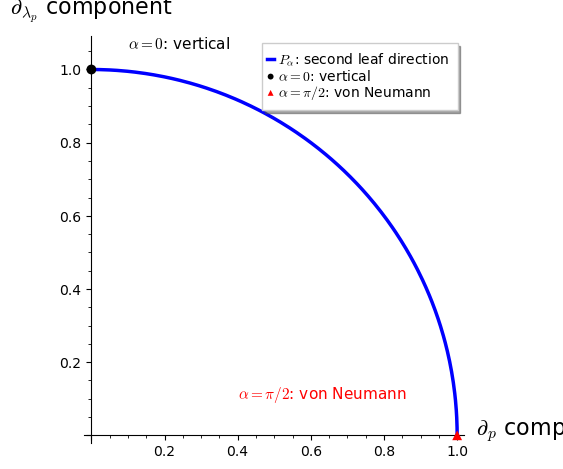

In [4]:
import os

os.makedirs('figures', exist_ok=True)

# (d_p component, d_lambda_p component) = (sin t, cos t), t in [0, pi/2].
# Sage-native plotting: matplotlib's PDF backend does not accept Sage number types.
var('t')
fig = parametric_plot((sin(t), cos(t)), (t, 0, pi/2),
                      color='blue', thickness=2.5,
                      legend_label=r'$P_\alpha$: second leaf direction')

fig += point((0, 1), size=50, color='black', zorder=5,
             legend_label=r'$\alpha=0$: vertical')
fig += point((1, 0), size=50, color='red', marker='^', zorder=5,
             legend_label=r'$\alpha=\pi/2$: von Neumann')

fig += text(r'$\alpha=0$: vertical',   (0.10, 1.07), fontsize=11, color='black',
            horizontal_alignment='left')
fig += text(r'$\alpha=\pi/2$: von Neumann', (0.40, 0.11), fontsize=11, color='red',
            horizontal_alignment='left')

fig.axes_labels([r'$\partial_p$ component', r'$\partial_{\lambda_p}$ component'])
fig.set_aspect_ratio(1)

fig.save('figures/P_alpha_curve.pdf')
fig.save('figures/P_alpha_curve.png', dpi=150)
fig.show()

## 4. The limit $\alpha\to0$

The curve is continuous at its vertical end: $\lim_{\alpha\to0}P_\alpha=P_0$ symbolically, and the Frobenius distance $\|P_\alpha-P_0\|_F$ shrinks with $\alpha$.

On the operator side, in the variables $u=x-\tfrac{\hbar\kappa}{2}\lambda_p$, $v=x+\tfrac{\hbar\kappa}{2}\lambda_p$ the second-order part of the evolution equation has coefficient $(\hbar\kappa)^2/2m$, which tends to zero with $\kappa$. The coefficient alone does not give the convergence of the solutions; that is checked in C7.

In [5]:
# Symbolic limit of the curve
P_lim = matrix([[limit(P_alpha[i,j], alpha=0) for j in range(4)] for i in range(2)])
assert P_lim == P0, f"lim P_alpha != P0; got {P_lim}"
print("OK: lim_{α→0} P_α = P_0")

import math
alpha_vals = [1.0, 0.1, 0.01]
print("||P_α − P_0||_F for decreasing α:")
for av in alpha_vals:
    diff_mat = P_alpha.subs(alpha=av) - P0
    frob = float(sum(diff_mat[i,j]^2 for i in range(2) for j in range(4)))^0.5
    print(f"  α = {av:4.2f}: ||P_α − P_0||_F = {frob:.4f}")

# Coefficient (hbar*kappa)^2/(2m)
var('hbar m kappa')
assume(hbar > 0, m > 0)
coeff = (hbar*kappa)^2 / (2*m)
kappa_vals = [1.0, 0.1, 0.01]
print("(ħκ)²/(2m) for decreasing κ, with ħ = m = 1:")
for kv in kappa_vals:
    val = float(coeff.subs(kappa=kv, hbar=1, m=1))
    print(f"  κ = {kv:4.2f}: (ħκ)²/(2m) = {val:.4f}")

OK: lim_{α→0} P_α = P_0
||P_α − P_0||_F for decreasing α:
  α = 1.00: ||P_α − P_0||_F = 0.9589
  α = 0.10: ||P_α − P_0||_F = 0.1000
  α = 0.01: ||P_α − P_0||_F = 0.0100
(ħκ)²/(2m) for decreasing κ, with ħ = m = 1:
  κ = 1.00: (ħκ)²/(2m) = 0.5000
  κ = 0.10: (ħκ)²/(2m) = 0.0050
  κ = 0.01: (ħκ)²/(2m) = 0.0001


## Final check

In [6]:
final_iso = (P_alpha * J * P_alpha.T).apply_map(lambda e: e.simplify_trig())
assert final_iso.is_zero(), f"isotropy fails on re-check: {final_iso}"

assert os.path.exists('figures/P_alpha_curve.pdf'), "figures/P_alpha_curve.pdf not found"
assert os.path.exists('figures/P_alpha_curve.png'), "figures/P_alpha_curve.png not found"

print("C3: all checks passed.")

C3: all checks passed.
